In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(ggpubr)
  require(dplyr)
})
meta <- as.data.table(readxl::read_excel("../../data/figure-inputs/metadata/ndmm-rrmm-metadata-2025.xlsx", sheet = 1))
FH1 <- fread("../../data/figure-inputs/msd/flu_response_cv_classification.csv")
sex_comparison <- left_join(distinct(FH1[, c("Subject", "Responder")]), distinct(meta[, c("Subject", "Sex")]))

Joining with `by = join_by(Subject)`


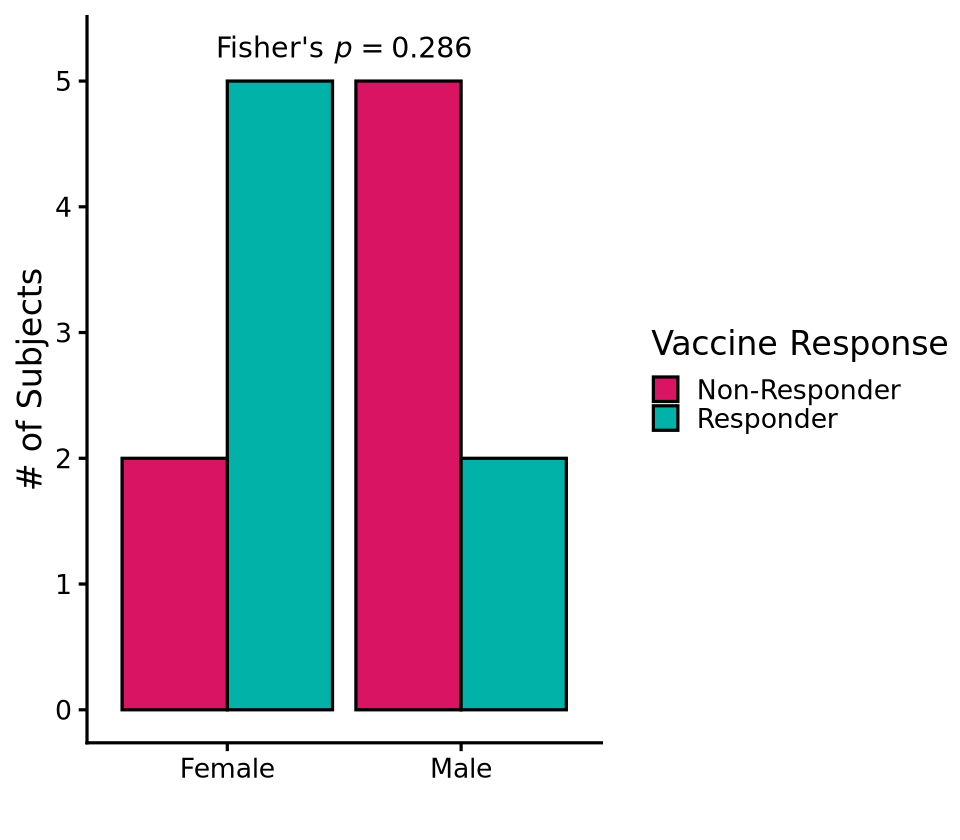

In [2]:
options(repr.plot.width = 8, repr.plot.height = 7)

counts <- as.data.table(sex_comparison)[, .N, by = .(Sex, Responder)]

tbl <- table(sex_comparison$Sex, sex_comparison$Responder)
ft <- fisher.test(tbl)
pval <- ft$p.value

p <- ggplot(counts, aes(x = Sex, y = N, fill = Responder)) +
  geom_col(position = "dodge", color = "black") +
  scale_fill_manual(values = c("Non-Responder" = "#d81463", "Responder" = "#00b2a8")) +
  labs(
    x = "", y = "# of Subjects", fill = "Vaccine Response"
  ) +
  annotate("text",
    x = 1.5, y = max(counts$N) * 1.05,
    label = paste0("\"Fisher's\" ~ italic(p) == ", signif(pval, 3)), parse = TRUE, size = 6
  ) +
  theme_classic(base_size = 20) +
  theme(
    legend.position = "right",
    plot.title = element_text(face = "bold")
  )
p
ggsave("../../data/figure-outputs/supplementary-7/sup_7d.pdf", plot = p, width = 6, height = 7, dpi = 200, device = cairo_pdf)